# Assignment – Week 4
## Logistic Regression: R → Python Bridge

**Course:** Data Science  
**Submission:** Jupyter Notebook (.ipynb)  
**Dataset:** `housing.csv`

---

## Learning Objectives

By the end of this assignment, you should be able to:

- Fit and interpret **logistic regression models**
- Translate workflows from **R (glm / tidymodels)** to **Python**
- Interpret **odds ratios**
- Evaluate classification models using **Accuracy and ROC–AUC**
- Reflect on the difference between **statistical inference vs prediction**

---

## Dataset Description

The dataset contains **600 housing listings**.

| Variable | Description |
|---|---|
| listing_id | Unique identifier |
| price | Sale price of the house |
| size | House size (square footage) |
| bedrooms | Number of bedrooms |
| neighborhood | Location category |
| type | Housing type (SingleFamily, Townhouse, MultiFamily) |

---
## Setup — Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay

df = pd.read_csv('https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv')
print(df.shape)
df.head()

(600, 6)


,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


---
## Step 0 – Create a Binary Outcome

For classification, convert `price` into a binary variable:

- `1` → expensive homes (above median price)
- `0` → less expensive homes (at or below median price)

In [3]:
df['high_price'] = (df['price'] > df['price'].median()).astype(int)

print('Median price: $', df['price'].median())
print(df['high_price'].value_counts())

Median price: $ 201165.0
high_price
0    300
1    300
Name: count, dtype: int64


---
## Part E – Explore the Dataset

Before modeling, create at least three exploratory plots and discuss one interesting pattern.

/tmp/ipykernel_8519/1285989280.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data_by_hood, labels=neighborhoods, patch_artist=True,


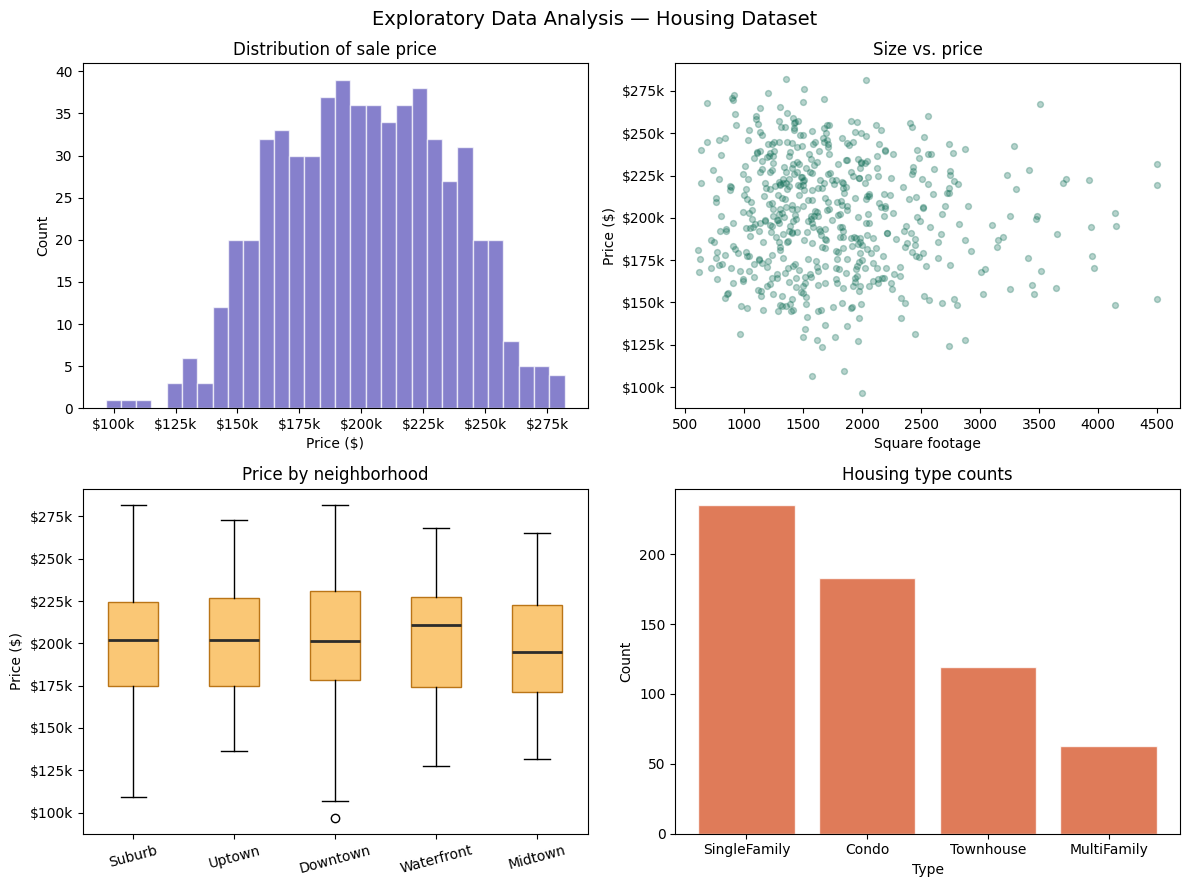

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Exploratory Data Analysis — Housing Dataset', fontsize=14)

# 1. Histogram of price
axes[0, 0].hist(df['price'].dropna(), bins=30, color='#534AB7', alpha=0.7, edgecolor='white')
axes[0, 0].set_title('Distribution of sale price')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# 2. Scatter: size vs price
axes[0, 1].scatter(df['size'], df['price'], alpha=0.3, s=18, color='#0F6E56')
axes[0, 1].set_title('Size vs. price')
axes[0, 1].set_xlabel('Square footage')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# 3. Boxplot: price by neighborhood
neighborhoods = df['neighborhood'].dropna().unique()
data_by_hood = [df.loc[df['neighborhood'] == n, 'price'].dropna() for n in neighborhoods]
axes[1, 0].boxplot(data_by_hood, labels=neighborhoods, patch_artist=True,
                   boxprops=dict(facecolor='#FAC775', color='#BA7517'),
                   medianprops=dict(color='#2C2C2A', linewidth=2))
axes[1, 0].set_title('Price by neighborhood')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Bar chart: housing type
type_counts = df['type'].value_counts()
axes[1, 1].bar(type_counts.index, type_counts.values, color='#D85A30', alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Housing type counts')
axes[1, 1].set_xlabel('Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

### Your Response — Interesting Pattern

*Discuss one interesting pattern you observed in the plots above.*

> It seems like there is no difference between size and price. Also regardless of neighborhood, it seems like the median prices are basically the same.

---
## Part A – Logistic Regression for Inference

Fit a logistic regression model using `statsmodels` to understand which variables are associated with a house being expensive.

In [6]:
df_clean = df.dropna(subset=['high_price', 'size', 'bedrooms', 'neighborhood'])

logit_model = smf.logit(
    'high_price ~ size + bedrooms + C(neighborhood)',
    data=df_clean
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                 0.01177
Time:                        00:48:06   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

In [7]:
# Build odds ratio table
odds_table = pd.DataFrame({
    'Coefficient': logit_model.params,
    'Odds Ratio':  np.exp(logit_model.params),
    'p-value':     logit_model.pvalues
}).round(4)

odds_table['Significant'] = odds_table['p-value'] < 0.05
print(odds_table)

                               Coefficient  Odds Ratio  p-value  Significant
Intercept                           0.3796      1.4616   0.1897        False
C(neighborhood)[T.Midtown]         -0.3065      0.7360   0.2784        False
C(neighborhood)[T.Suburb]           0.1071      1.1130   0.6752        False
C(neighborhood)[T.Uptown]           0.0470      1.0482   0.8648        False
C(neighborhood)[T.Waterfront]       0.4130      1.5114   0.2431        False
size                               -0.0005      0.9995   0.0367         True
bedrooms                            0.2322      1.2614   0.0822        False


### Your Response — Short Analysis

Answer both questions using the table above.

**Which predictors appear statistically significant?**

> It seems like `size` is the only one which is statistically significant. `bedrooms` seems to be marginally significant since it is very close to the threshold of 0.05.

> Something worth noting though is that the model overall is very weak since it has a `R²` of 0.012 and `LLR p-value` of 0.20 which tell us that even though `size` is technically significant, the whole model barely does better than just guessing "expensive" or "not expensive" for every house.

**Which neighborhood has higher odds of expensive homes?**

> Waterfront.

---
## Part B – Interpretation in Plain Language

Choose **one variable** from the odds ratio table above and explain what its odds ratio means to someone without a statistics background.

Example template:
> *"For every additional bedroom, the odds of a house being expensive increase by ___."*

### Your Response

> For each additional bedroom, the odds of a house being expensive are multiplied by 1.26 — about 26% higher odds.

---
## Part C – Prediction Workflow (tidymodels → scikit-learn)

### 1. Train / Test Split

In [8]:
features = ['size', 'bedrooms', 'neighborhood', 'type']
target   = 'high_price'

df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training rows: {len(X_train)}  |  Test rows: {len(X_test)}')

Training rows: 419  |  Test rows: 105


### 2. Fit Logistic Regression

In [9]:
numeric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe,     ['size', 'bedrooms']),
    ('cat', categorical_pipe, ['neighborhood', 'type'])
])

clf = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)
print('Model fitted successfully.')

Model fitted successfully.


### 3. Evaluate the Model

In [10]:
y_pred      = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

Accuracy : 0.4667
ROC-AUC  : 0.4394


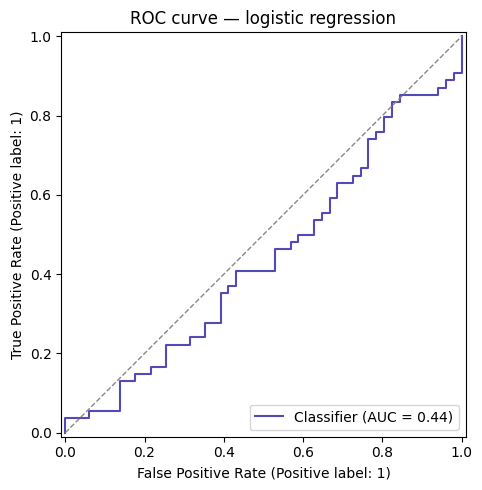

In [11]:
# Optional: ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=ax, color='#534AB7')
ax.plot([0, 1], [0, 1], linestyle='--', color='#888780', linewidth=1)
ax.set_title('ROC curve — logistic regression')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part D – Model Understanding

### Accuracy vs ROC–AUC

Why might **ROC–AUC** sometimes be preferred over **accuracy**? Answer in 2–3 sentences.

### Response

> Accuracy can be misleading when one class is much more common than the other — a model that always predicts the majority class will score high accuracy while being useless. ROC–AUC measures how well the model separates the two classes regardless of their balance, making it a more honest measure of real performance.

### Inference vs Prediction

Which modeling approach would you choose for each task, and why?

Key:
- A = stats.model
- B = scikit-learn
- 1 = Policy Analysis explaination
- 2 = Prediction Tasks explaination

| Task | Approach | Why |
|---|---|---|
| Policy analysis | A | 1 |
| Prediction tasks | B | 2 |

1. To be able to make a decision on something, you need to be able to provide an explaination of why something is the way it is and the statistics provided by the `stats.model` will help explain why we got our results.

2. For prediction tasks, something could be statistically significant (i.e. not due to random chance), but it does not mean it is a good predictor. Therefore, we need to use `scikit-learn` since it does not take into account whether or not the variable is statistically significant. It just cares how well the model works for predicting the outcome.